# **CS3244 Group Project - SVM model**
## Load Dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# load the dataset
def load_data():
    X_train = np.loadtxt("/kaggle/input/3244project/Train/X_train.txt")
    y_train = np.loadtxt("/kaggle/input/3244project/Train/y_train.txt").astype(int)
    X_test = np.loadtxt("/kaggle/input/3244project/Test/X_test.txt")
    y_test = np.loadtxt("/kaggle/input/3244project/Test/y_test.txt").astype(int)
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data()

## Data Pre-processing

In [2]:

from sklearn.decomposition import PCA

def apply_pca(X_train, X_test, n_components=300):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    return X_train_pca, X_test_pca

X_train_pca, X_test_pca = apply_pca(X_train, X_test, n_components=300)


from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy={7: 100, 8: 100, 9: 300, 10: 100, 11: 100, 12: 300}, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_pca, y_train)


## Testing Different Types of SVM

In [3]:
# Linear SVM

from sklearn.svm import LinearSVC
svm = LinearSVC(C=10, max_iter=5000)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9478178368121443
Classification Report:
               precision    recall  f1-score   support

           1       0.95      1.00      0.97       496
           2       0.98      0.95      0.96       471
           3       1.00      0.99      0.99       420
           4       0.96      0.89      0.92       508
           5       0.91      0.97      0.94       556
           6       0.99      1.00      0.99       545
           7       0.74      0.61      0.67        23
           8       0.83      1.00      0.91        10
           9       0.58      0.59      0.58        32
          10       0.68      0.68      0.68        25
          11       0.65      0.61      0.63        49
          12       0.67      0.59      0.63        27

    accuracy                           0.95      3162
   macro avg       0.83      0.82      0.82      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[494   2   0   0   0   0   0   0   0   0   0   0]
 [ 21 447 

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [4]:
# Polynomial SVM

svm = SVC(kernel='poly', degree=2, C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9550917141049968
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.98       496
           2       0.97      0.96      0.96       471
           3       0.99      0.97      0.98       420
           4       0.97      0.89      0.93       508
           5       0.91      0.98      0.94       556
           6       1.00      1.00      1.00       545
           7       0.95      0.83      0.88        23
           8       1.00      1.00      1.00        10
           9       0.70      0.81      0.75        32
          10       0.76      0.76      0.76        25
          11       0.78      0.71      0.74        49
          12       0.75      0.67      0.71        27

    accuracy                           0.96      3162
   macro avg       0.89      0.88      0.89      3162
weighted avg       0.96      0.96      0.95      3162

Confusion Matrix:
 [[492   2   2   0   0   0   0   0   0   0   0   0]
 [ 17 452 

In [5]:
# RBF SVM

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9516129032258065
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.97       496
           2       0.95      0.96      0.96       471
           3       0.99      0.95      0.97       420
           4       0.97      0.90      0.93       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.78      0.86        23
           8       0.91      1.00      0.95        10
           9       0.65      0.75      0.70        32
          10       0.77      0.80      0.78        25
          11       0.74      0.69      0.72        49
          12       0.78      0.67      0.72        27

    accuracy                           0.95      3162
   macro avg       0.88      0.87      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[489   5   2   0   0   0   0   0   0   0   0   0]
 [ 16 454 

In [6]:
# Class-weighted SVM

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)

svm = SVC(kernel='rbf', C=10, gamma="scale", class_weight=dict(zip(classes, class_weights)))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9497153700189753
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.97       496
           2       0.94      0.97      0.95       471
           3       1.00      0.93      0.96       420
           4       0.96      0.91      0.93       508
           5       0.93      0.97      0.95       556
           6       1.00      1.00      1.00       545
           7       0.90      0.83      0.86        23
           8       0.91      1.00      0.95        10
           9       0.68      0.66      0.67        32
          10       0.73      0.76      0.75        25
          11       0.71      0.73      0.72        49
          12       0.74      0.63      0.68        27

    accuracy                           0.95      3162
   macro avg       0.87      0.86      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[490   5   1   0   0   0   0   0   0   0   0   0]
 [ 15 455 

In [7]:
# One-vs-One SVM

from sklearn.multiclass import OneVsOneClassifier

svm = OneVsOneClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9519291587602783
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.98      0.97       496
           2       0.95      0.97      0.96       471
           3       0.99      0.95      0.97       420
           4       0.97      0.90      0.93       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.78      0.86        23
           8       0.91      1.00      0.95        10
           9       0.66      0.78      0.71        32
          10       0.77      0.80      0.78        25
          11       0.74      0.71      0.73        49
          12       0.78      0.67      0.72        27

    accuracy                           0.95      3162
   macro avg       0.88      0.88      0.88      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[488   5   3   0   0   0   0   0   0   0   0   0]
 [ 15 455 

In [8]:
# One-vs-Rest SVM

from sklearn.multiclass import OneVsRestClassifier

svm = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9500316255534472
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.99      0.96       496
           2       0.95      0.95      0.95       471
           3       1.00      0.96      0.98       420
           4       0.97      0.89      0.93       508
           5       0.91      0.97      0.94       556
           6       1.00      1.00      1.00       545
           7       1.00      0.70      0.82        23
           8       0.91      1.00      0.95        10
           9       0.71      0.75      0.73        32
          10       0.74      0.80      0.77        25
          11       0.74      0.69      0.72        49
          12       0.74      0.63      0.68        27

    accuracy                           0.95      3162
   macro avg       0.88      0.86      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[489   6   1   0   0   0   0   0   0   0   0   0]
 [ 22 449 

## Hyperparametre Tuning

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

class CustomSVM(SVC):
    def __init__(self, kernel='rbf', C=23, gamma='scale', class_weight=None, tol=1e-3, max_iter=5000):
        super().__init__(kernel=kernel, C=C, gamma=gamma, class_weight=class_weight, tol=tol, max_iter=max_iter, probability=True, shrinking=False, decision_function_shape='ovo')

    def _init_params(self, X, y):
        self.coef_ = np.random.uniform(-0.01, 0.01, size=X.shape[1])
        self.intercept_ = np.random.uniform(-0.01, 0.01)
        super()._init_params(X, y)


param_grid = {
    "C": [1, 10, 23],  
    "gamma": [0.1, 1, "scale"],  
    "kernel": ["rbf"]
}

cv = StratifiedKFold(n_splits=5)
svm = GridSearchCV(CustomSVM(), param_grid, cv=cv, n_jobs=-1)
svm.fit(X_train, y_train)

y_pred = svm.best_estimator_.predict(X_test)
y_prob = svm.best_estimator_.predict_proba(X_test)
print("Best Parameters:", svm.best_params_)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Parameters: {'C': 23, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.9557242251739405
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.98       496
           2       0.95      0.97      0.96       471
           3       1.00      0.95      0.97       420
           4       0.97      0.91      0.94       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.83      0.88        23
           8       0.91      1.00      0.95        10
           9       0.70      0.72      0.71        32
          10       0.81      0.84      0.82        25
          11       0.73      0.73      0.73        49
          12       0.83      0.70      0.76        27

    accuracy                           0.96      3162
   macro avg       0.89      0.88      0.89      3162
weighted avg       0.96      0.96      0.96      3162

Confusion Matrix:


## Evaluation

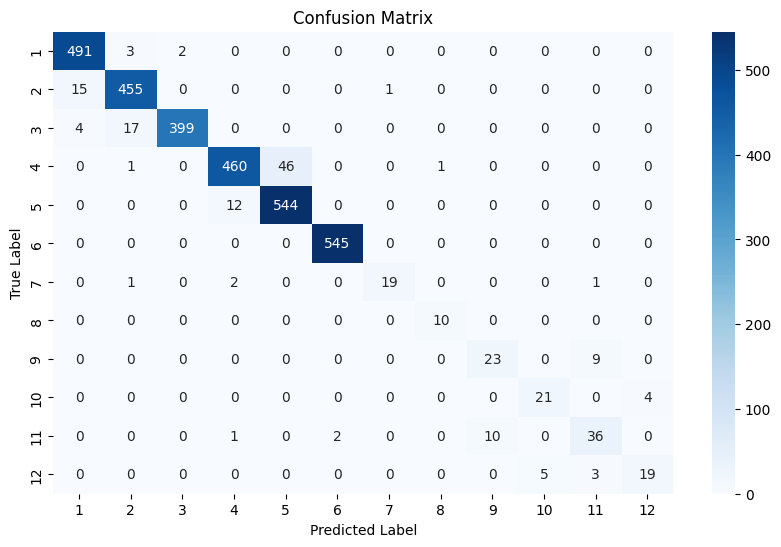

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# visualize
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

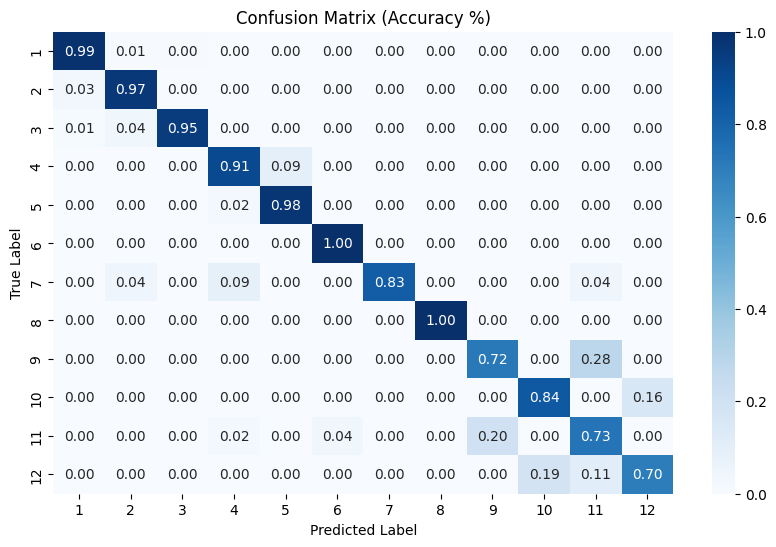

In [12]:
conf_matrix_normalized = conf_matrix.astype(np.float32) / conf_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(1, 13), yticklabels=range(1, 13))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Accuracy %)")
plt.show()

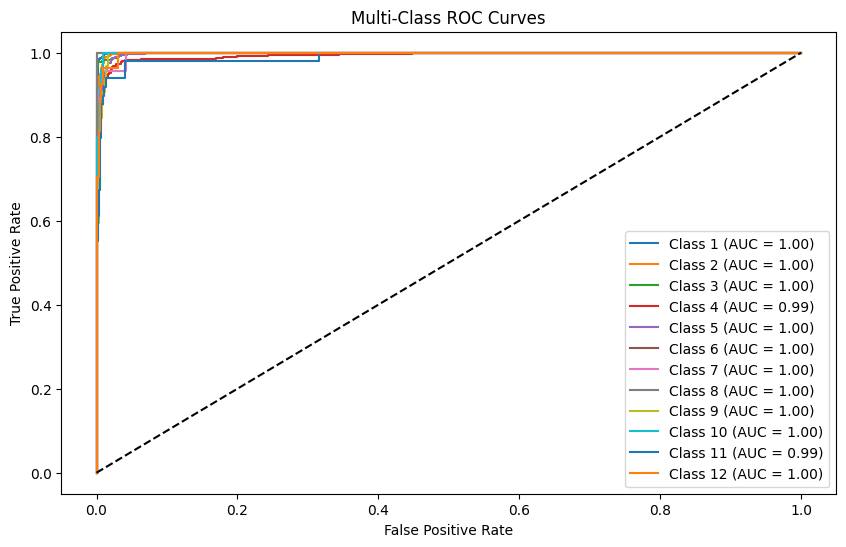

In [13]:
from sklearn.preprocessing import label_binarize

# One-vs-Rest
y_test_bin = label_binarize(y_test, classes=np.arange(1, 13))  # 12 One-vs-All
n_classes = y_test_bin.shape[1]

# compute ROC-AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i+1} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curves")
plt.legend(loc="lower right")
plt.show()

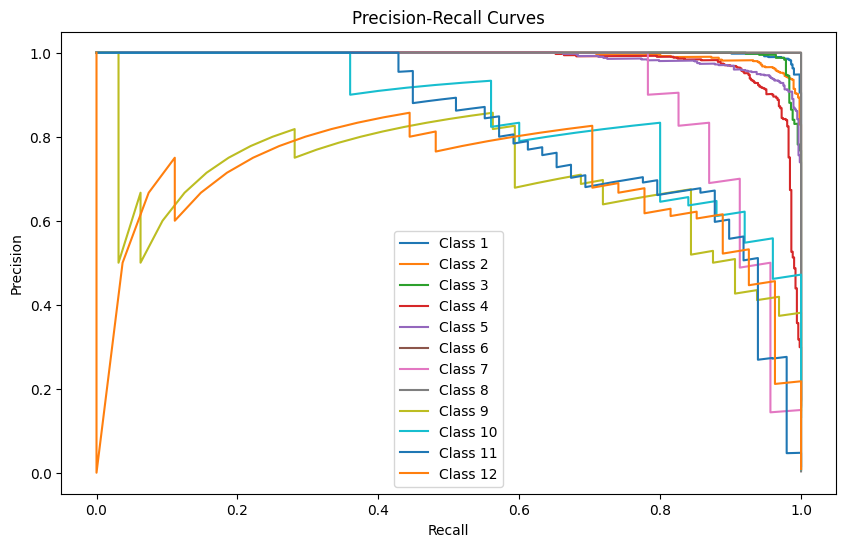

In [14]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"Class {i+1}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()